# Feature Selection

In [29]:
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.preprocessing import StandardScaler, TargetEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import optuna
import warnings
import numpy as np
import json
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

In [30]:
# Load the processed datasets
X_train_transformed = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')
X_test_transformed = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')
# Load not processed datasets
X_train = pd.read_csv('../data/not_processed/X_train.csv')
X_test = pd.read_csv('../data/not_processed/y_train.csv')

In [31]:
# Label encoding for target variable
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test.values)

## Logistic Regression

In [13]:
# Optuna for Logistic Regression
def objective(trial):
    C = trial.suggest_float('C', 0.0001, 100.0, log=True)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    max_iter = trial.suggest_int('max_iter', 100, 10000)
    model = LogisticRegression(C=C, class_weight=class_weight, max_iter=max_iter, random_state=42, n_jobs=-1)
    scores = cross_val_score(model, X_train_transformed, y_train, cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42), scoring='f1_macro')
    return np.mean(scores)
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50,show_progress_bar=True)

[I 2026-05-03 15:15:46,452] A new study created in memory with name: no-name-ef79d502-0f66-4fa5-ba91-10dcec803d55
Best trial: 0. Best value: 0.749869:   2%|▏         | 1/50 [00:00<00:13,  3.62it/s]

[I 2026-05-03 15:15:46,727] Trial 0 finished with value: 0.749869128857301 and parameters: {'C': 0.4159040974080179, 'class_weight': None, 'max_iter': 5644}. Best is trial 0 with value: 0.749869128857301.


Best trial: 1. Best value: 0.752717:   4%|▍         | 2/50 [00:00<00:12,  3.79it/s]

[I 2026-05-03 15:15:46,983] Trial 1 finished with value: 0.7527173329367972 and parameters: {'C': 1.0682920133308527, 'class_weight': None, 'max_iter': 6517}. Best is trial 1 with value: 0.7527173329367972.


Best trial: 1. Best value: 0.752717:   8%|▊         | 4/50 [00:00<00:10,  4.44it/s]

[I 2026-05-03 15:15:47,203] Trial 2 finished with value: 0.7413887312244611 and parameters: {'C': 0.10583739870142318, 'class_weight': 'balanced', 'max_iter': 2649}. Best is trial 1 with value: 0.7527173329367972.
[I 2026-05-03 15:15:47,400] Trial 3 finished with value: 0.7442300776384515 and parameters: {'C': 0.2934883755026824, 'class_weight': 'balanced', 'max_iter': 4267}. Best is trial 1 with value: 0.7527173329367972.


Best trial: 4. Best value: 0.756585:  12%|█▏        | 6/50 [00:01<00:10,  4.38it/s]

[I 2026-05-03 15:15:47,752] Trial 4 finished with value: 0.7565851740582159 and parameters: {'C': 9.952394410374215, 'class_weight': None, 'max_iter': 5479}. Best is trial 4 with value: 0.7565851740582159.
[I 2026-05-03 15:15:47,897] Trial 5 finished with value: 0.7377987771764479 and parameters: {'C': 0.048556235165618154, 'class_weight': 'balanced', 'max_iter': 3962}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  12%|█▏        | 6/50 [00:01<00:10,  4.38it/s]

[I 2026-05-03 15:15:47,995] Trial 6 finished with value: 0.49990726145739206 and parameters: {'C': 0.0005079021158707052, 'class_weight': None, 'max_iter': 2411}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  18%|█▊        | 9/50 [00:02<00:09,  4.46it/s]

[I 2026-05-03 15:15:48,416] Trial 7 finished with value: 0.7403333608256242 and parameters: {'C': 21.15632203927001, 'class_weight': 'balanced', 'max_iter': 5740}. Best is trial 4 with value: 0.7565851740582159.
[I 2026-05-03 15:15:48,586] Trial 8 finished with value: 0.7443558549019121 and parameters: {'C': 0.12487361996131152, 'class_weight': 'balanced', 'max_iter': 7792}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  20%|██        | 10/50 [00:02<00:09,  4.11it/s]

[I 2026-05-03 15:15:48,881] Trial 9 finished with value: 0.740141328254448 and parameters: {'C': 1.1379623099158547, 'class_weight': 'balanced', 'max_iter': 3460}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  22%|██▏       | 11/50 [00:02<00:11,  3.53it/s]

[I 2026-05-03 15:15:49,267] Trial 10 finished with value: 0.7559312850083413 and parameters: {'C': 50.954429607706295, 'class_weight': None, 'max_iter': 612}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  24%|██▍       | 12/50 [00:03<00:11,  3.26it/s]

[I 2026-05-03 15:15:49,633] Trial 11 finished with value: 0.7558771220210371 and parameters: {'C': 71.06966610263807, 'class_weight': None, 'max_iter': 124}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  26%|██▌       | 13/50 [00:03<00:11,  3.17it/s]

[I 2026-05-03 15:15:49,970] Trial 12 finished with value: 0.7565539316275781 and parameters: {'C': 7.829804927822093, 'class_weight': None, 'max_iter': 421}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  28%|██▊       | 14/50 [00:03<00:11,  3.04it/s]

[I 2026-05-03 15:15:50,333] Trial 13 finished with value: 0.7559605829282974 and parameters: {'C': 9.004863236891639, 'class_weight': None, 'max_iter': 9702}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  32%|███▏      | 16/50 [00:04<00:08,  3.81it/s]

[I 2026-05-03 15:15:50,646] Trial 14 finished with value: 0.7559460288920158 and parameters: {'C': 6.4441815279975625, 'class_weight': None, 'max_iter': 7514}. Best is trial 4 with value: 0.7565851740582159.
[I 2026-05-03 15:15:50,760] Trial 15 finished with value: 0.7307583701132396 and parameters: {'C': 0.007545346046244526, 'class_weight': None, 'max_iter': 1439}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  36%|███▌      | 18/50 [00:04<00:07,  4.37it/s]

[I 2026-05-03 15:15:51,067] Trial 16 finished with value: 0.7555273397018027 and parameters: {'C': 3.6031379964842483, 'class_weight': None, 'max_iter': 4979}. Best is trial 4 with value: 0.7565851740582159.
[I 2026-05-03 15:15:51,186] Trial 17 finished with value: 0.7419446068115092 and parameters: {'C': 0.015363292354836416, 'class_weight': None, 'max_iter': 9295}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  36%|███▌      | 18/50 [00:04<00:07,  4.37it/s]

[I 2026-05-03 15:15:51,279] Trial 18 finished with value: 0.45322288316743853 and parameters: {'C': 0.00040458801264137617, 'class_weight': None, 'max_iter': 7246}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  40%|████      | 20/50 [00:05<00:06,  4.50it/s]

[I 2026-05-03 15:15:51,614] Trial 19 finished with value: 0.7561847232363653 and parameters: {'C': 3.5508587186950122, 'class_weight': None, 'max_iter': 1916}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  42%|████▏     | 21/50 [00:05<00:07,  3.83it/s]

[I 2026-05-03 15:15:51,994] Trial 20 finished with value: 0.7564372625473446 and parameters: {'C': 18.37737959324104, 'class_weight': None, 'max_iter': 8541}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  44%|████▍     | 22/50 [00:05<00:07,  3.57it/s]

[I 2026-05-03 15:15:52,327] Trial 21 finished with value: 0.7558310723680771 and parameters: {'C': 18.64744295610839, 'class_weight': None, 'max_iter': 9333}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  46%|████▌     | 23/50 [00:06<00:08,  3.23it/s]

[I 2026-05-03 15:15:52,718] Trial 22 finished with value: 0.7552167973469538 and parameters: {'C': 80.58927076490642, 'class_weight': None, 'max_iter': 8350}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 4. Best value: 0.756585:  48%|████▊     | 24/50 [00:06<00:07,  3.35it/s]

[I 2026-05-03 15:15:52,986] Trial 23 finished with value: 0.7542607590379935 and parameters: {'C': 1.6490829778331138, 'class_weight': None, 'max_iter': 6512}. Best is trial 4 with value: 0.7565851740582159.


Best trial: 24. Best value: 0.756964:  50%|█████     | 25/50 [00:06<00:07,  3.16it/s]

[I 2026-05-03 15:15:53,348] Trial 24 finished with value: 0.7569642490365756 and parameters: {'C': 21.96613825862285, 'class_weight': None, 'max_iter': 8657}. Best is trial 24 with value: 0.7569642490365756.


Best trial: 24. Best value: 0.756964:  52%|█████▏    | 26/50 [00:07<00:08,  2.96it/s]

[I 2026-05-03 15:15:53,738] Trial 25 finished with value: 0.7566385942638447 and parameters: {'C': 23.395931647101236, 'class_weight': None, 'max_iter': 4838}. Best is trial 24 with value: 0.7569642490365756.


Best trial: 24. Best value: 0.756964:  54%|█████▍    | 27/50 [00:07<00:07,  2.92it/s]

[I 2026-05-03 15:15:54,090] Trial 26 finished with value: 0.7559410566544753 and parameters: {'C': 27.599485110450416, 'class_weight': None, 'max_iter': 4478}. Best is trial 24 with value: 0.7569642490365756.


Best trial: 24. Best value: 0.756964:  58%|█████▊    | 29/50 [00:08<00:06,  3.48it/s]

[I 2026-05-03 15:15:54,512] Trial 27 finished with value: 0.7555786831593554 and parameters: {'C': 93.97075965814214, 'class_weight': None, 'max_iter': 3473}. Best is trial 24 with value: 0.7569642490365756.
[I 2026-05-03 15:15:54,614] Trial 28 finished with value: 0.6647383255540734 and parameters: {'C': 0.0018080055712719522, 'class_weight': None, 'max_iter': 6581}. Best is trial 24 with value: 0.7569642490365756.


Best trial: 24. Best value: 0.756964:  60%|██████    | 30/50 [00:08<00:05,  3.79it/s]

[I 2026-05-03 15:15:54,822] Trial 29 finished with value: 0.749869128857301 and parameters: {'C': 0.3873211765816237, 'class_weight': None, 'max_iter': 5878}. Best is trial 24 with value: 0.7569642490365756.


Best trial: 24. Best value: 0.756964:  62%|██████▏   | 31/50 [00:08<00:05,  3.52it/s]

[I 2026-05-03 15:15:55,155] Trial 30 finished with value: 0.7561847232363653 and parameters: {'C': 3.2863434328782595, 'class_weight': None, 'max_iter': 5009}. Best is trial 24 with value: 0.7569642490365756.


Best trial: 31. Best value: 0.757114:  64%|██████▍   | 32/50 [00:09<00:05,  3.22it/s]

[I 2026-05-03 15:15:55,527] Trial 31 finished with value: 0.7571137105214532 and parameters: {'C': 7.667732166122238, 'class_weight': None, 'max_iter': 1252}. Best is trial 31 with value: 0.7571137105214532.


Best trial: 31. Best value: 0.757114:  66%|██████▌   | 33/50 [00:09<00:05,  3.09it/s]

[I 2026-05-03 15:15:55,882] Trial 32 finished with value: 0.7558227212260833 and parameters: {'C': 33.02615486199359, 'class_weight': None, 'max_iter': 1319}. Best is trial 31 with value: 0.7571137105214532.


Best trial: 33. Best value: 0.757607:  68%|██████▊   | 34/50 [00:09<00:05,  2.96it/s]

[I 2026-05-03 15:15:56,254] Trial 33 finished with value: 0.7576068900974435 and parameters: {'C': 11.080264756788054, 'class_weight': None, 'max_iter': 3155}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  70%|███████   | 35/50 [00:10<00:04,  3.27it/s]

[I 2026-05-03 15:15:56,484] Trial 34 finished with value: 0.7517141832601979 and parameters: {'C': 0.7084324182316422, 'class_weight': None, 'max_iter': 3108}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  72%|███████▏  | 36/50 [00:10<00:04,  3.08it/s]

[I 2026-05-03 15:15:56,853] Trial 35 finished with value: 0.7403161530285549 and parameters: {'C': 1.3934530486064924, 'class_weight': 'balanced', 'max_iter': 2719}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  74%|███████▍  | 37/50 [00:10<00:04,  2.93it/s]

[I 2026-05-03 15:15:57,234] Trial 36 finished with value: 0.7565774658904865 and parameters: {'C': 13.854436087899927, 'class_weight': None, 'max_iter': 4041}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  78%|███████▊  | 39/50 [00:11<00:03,  3.50it/s]

[I 2026-05-03 15:15:57,526] Trial 37 finished with value: 0.7552555352231062 and parameters: {'C': 2.795091527111413, 'class_weight': None, 'max_iter': 2012}. Best is trial 33 with value: 0.7576068900974435.
[I 2026-05-03 15:15:57,714] Trial 38 finished with value: 0.7453815521789952 and parameters: {'C': 0.17176790860020744, 'class_weight': 'balanced', 'max_iter': 931}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  80%|████████  | 40/50 [00:11<00:03,  3.12it/s]

[I 2026-05-03 15:15:58,119] Trial 39 finished with value: 0.7561099625995495 and parameters: {'C': 31.684127516949278, 'class_weight': None, 'max_iter': 4520}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  84%|████████▍ | 42/50 [00:12<00:02,  3.66it/s]

[I 2026-05-03 15:15:58,463] Trial 40 finished with value: 0.7378067645093385 and parameters: {'C': 6.053746114199452, 'class_weight': 'balanced', 'max_iter': 3620}. Best is trial 33 with value: 0.7576068900974435.
[I 2026-05-03 15:15:58,606] Trial 41 finished with value: 0.06627082081311472 and parameters: {'C': 0.00010168547773895754, 'class_weight': None, 'max_iter': 5451}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  86%|████████▌ | 43/50 [00:12<00:02,  3.42it/s]

[I 2026-05-03 15:15:58,945] Trial 42 finished with value: 0.7561787583316395 and parameters: {'C': 11.8890494921609, 'class_weight': None, 'max_iter': 6220}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  88%|████████▊ | 44/50 [00:12<00:01,  3.05it/s]

[I 2026-05-03 15:15:59,354] Trial 43 finished with value: 0.7564728005573714 and parameters: {'C': 40.95201896403462, 'class_weight': None, 'max_iter': 2546}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  90%|█████████ | 45/50 [00:13<00:01,  3.32it/s]

[I 2026-05-03 15:15:59,594] Trial 44 finished with value: 0.7522805962826279 and parameters: {'C': 0.7597181701709497, 'class_weight': None, 'max_iter': 7048}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  92%|█████████▏| 46/50 [00:13<00:01,  3.07it/s]

[I 2026-05-03 15:15:59,976] Trial 45 finished with value: 0.7381938481094734 and parameters: {'C': 5.923127984205325, 'class_weight': 'balanced', 'max_iter': 2991}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  94%|█████████▍| 47/50 [00:13<00:00,  3.12it/s]

[I 2026-05-03 15:16:00,283] Trial 46 finished with value: 0.7547839586076591 and parameters: {'C': 2.0997252309908987, 'class_weight': None, 'max_iter': 8145}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607:  98%|█████████▊| 49/50 [00:14<00:00,  3.55it/s]

[I 2026-05-03 15:16:00,679] Trial 47 finished with value: 0.7561952847797123 and parameters: {'C': 48.8238498485127, 'class_weight': None, 'max_iter': 5440}. Best is trial 33 with value: 0.7576068900974435.
[I 2026-05-03 15:16:00,819] Trial 48 finished with value: 0.7441945498787017 and parameters: {'C': 0.04628518257400842, 'class_weight': None, 'max_iter': 2110}. Best is trial 33 with value: 0.7576068900974435.


Best trial: 33. Best value: 0.757607: 100%|██████████| 50/50 [00:14<00:00,  3.39it/s]

[I 2026-05-03 15:16:01,188] Trial 49 finished with value: 0.7554673352150594 and parameters: {'C': 11.636720120411901, 'class_weight': None, 'max_iter': 1442}. Best is trial 33 with value: 0.7576068900974435.


In [ ]:
# Train the final model with the best hyperparameters
lr = LogisticRegression(**study.best_params, random_state=42, n_jobs=-1)
lr.fit(X_train_transformed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",11.080264756788054
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- F

In [17]:
# Check Logistic Regression coefficients
feature_importance = pd.DataFrame({'feature': X_train_transformed.columns, 'importance': np.abs(lr.coef_[0])})
feature_importance = feature_importance.sort_values(by='importance', ascending=False)
feature_importance

,feature,importance
33,is_data_expert,3.109939
31,is_cloud_expert,0.941517
28,is_data_engineer,0.936467
14,problem_solving,0.602317
32,is_heavy_ml,0.581607
4,sql,0.540328
12,communication,0.465427
40,field_of_study_Cybersecurity,0.448013
25,de_score,0.324040
11,networking,0.308121


No feature has coef = 0, all features for linear models will be kept

## Catboost

In [32]:
# Categorical features
categorical_features = ['field_of_study']
# Split the training data into a shorter training set and a validation set for CatBoost feature selection
split_idx = int(len(X_train) * 0.8)

X_train_short, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_train_short, y_val = y_train[:split_idx], y_train[split_idx:]

train_pool = Pool(X_train_short, y_train_short, cat_features=categorical_features)
val_pool = Pool(X_val, y_val, cat_features=categorical_features)

In [33]:
# Initialize the CatBoostClassifier with basic parameters
model = CatBoostClassifier(iterations=500, learning_rate=0.05, verbose=0)
# Perform feature selection using RecursiveByShapValues algorithm to find the optimal number of features to select based on validation performance
summary = model.select_features(
    train_pool,
    eval_set=val_pool,
    features_for_select=list(range(X_train.shape[1])),
    num_features_to_select=1,  
    algorithm='RecursiveByShapValues',
    train_final_model=False,   
    logging_level='Silent',
)

loss_graph = summary['loss_graph']
steps  = np.array(loss_graph['removed_features_count'])
scores = np.array(loss_graph['loss_values'])

best_step = np.argmin(scores)
optimal_n_remove = steps[best_step]
optimal_n_select = X_train.shape[1] - optimal_n_remove

print(f"Remove: {optimal_n_remove}, Leave: {optimal_n_select}")

Remove: 4, Leave: 36


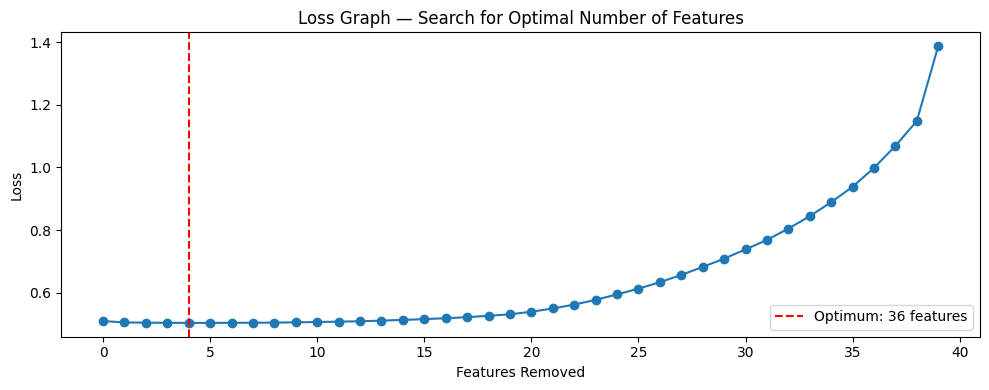

In [34]:
# Visualize the loss graph to identify the optimal number of features to select
plt.figure(figsize=(10, 4))
plt.plot(steps, scores, marker='o')
plt.axvline(optimal_n_remove, color='red', linestyle='--', label=f'Optimum: {optimal_n_select} features')
plt.xlabel('Features Removed')
plt.ylabel('Loss')
plt.title('Loss Graph — Search for Optimal Number of Features')
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
# Final feature selection using the optimal number of features identified from the loss graph
model2 = CatBoostClassifier(iterations=1000, learning_rate=0.05, verbose=0)

summary_final = model2.select_features(
    train_pool,
    eval_set=val_pool,
    features_for_select=list(range(X_train.shape[1])),
    num_features_to_select=optimal_n_select,  
    algorithm='RecursiveByShapValues',
    train_final_model=False,                 
    logging_level='Silent',
    steps=5
)

selected_features = summary_final['selected_features_names']
print(f"Selected: {len(selected_features)} features")
print(selected_features)

The number of features selection steps (5) is greater than the number of features to eliminate (4). The number of steps was reduced to 4.


Selected: 36 features
['field_of_study', 'gpa', 'python', 'java', 'c_cpp', 'machine_learning', 'data_analysis', 'cloud_computing', 'web_development', 'devops', 'networking', 'communication', 'leadership', 'problem_solving', 'teamwork', 'adaptability', 'tech_soft_ratio', 'ds_score', 'da_score', 'da_score_v2', 'ba_score', 'mle_score', 'de_score', 'se_score', 'ce_score', 'is_data_engineer', 'is_data_analyst', 'is_software_dev', 'is_cloud_expert', 'is_heavy_ml', 'is_data_expert', 'dev_vs_data', 'ml_vs_dev', 'analytics_no_infra', 'infra_no_analytics', 'da_vs_ds']


In [37]:
with open('../configs/selected_features_catboost.json', 'w') as f:
    json.dump(selected_features, f)